In [1]:
# for colab
try:
    import google.colab

    !curl -LsSf https://astral.sh/uv/install.sh | sh
    !git clone https://github.com/stanfish06/micropattern.git /tmp/micropattern
    !cp -r /tmp/micropattern/. .
    !rm -rf /tmp/micropattern
    !pip install -e .
    import sys

    sys.path.insert(0, "/content/src")

    # remember to upload aws credentials
    !mkdir -p ~/.aws
    !cp /content/credentials ~/.aws
    !ls ~/.aws
except ImportError:
    raise RuntimeError(
        "make sure to connect to colab kernel or code above will wipe locally"
    )

downloading uv 0.10.2 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Cloning into '/tmp/micropattern'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 178 (delta 100), reused 129 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (178/178), 5.75 MiB | 21.03 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Obtaining file:///content
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for micropattern (pyproject.toml) ... done
  Created wheel for micropattern: filename=micropattern-0.1.0-py3-none-any.whl size=1315 sha256=95c01b6f184d6137f84c4f5554389239f0a04aaf1e07a084f400ad5e745b110c
  Stored in directory: /tmp/pip-ephem-wheel-cache-u

In [12]:
!ps aux --sort=-%mem | head -20

USER         PID %CPU %MEM    VSZ   RSS TTY      STAT START   TIME COMMAND
root         122  0.1  0.2 657508 141180 ?       Sl   18:52   0:13 /usr/bin/python3 /usr/local/bin/jupyter-server --debug --transport="ipc" --ip=172.28.0.12 --ServerApp.token= --port=9000 --FileContentsManager.root_dir=/ --FileContentsManager.allow_hidden=True --ServerApp.log_format="|%(levelname)s|%(message)s" --ServerApp.iopub_data_rate_limit=1e10 --MappingKernelManager.root_dir=/content
root       31922  1.6  0.2 1063144 118340 ?      Ssl  21:00   0:02 /usr/bin/python3 -m colab_kernel_launcher -f /root/.local/share/jupyter/runtime/kernel-b01f4c98-58f0-4a71-828b-4d5a90e4cb9c.json
root       32495  9.7  0.1 912392 104732 ?       Ssl  21:02   0:01 /usr/bin/python3 -m colab_kernel_launcher -f /root/.local/share/jupyter/runtime/kernel-a5ee6d8f-8ec1-481a-b386-674651028be9.json
root          75  0.0  0.1 100748 66036 ?        S    18:52   0:01 python3 /usr/local/bin/colab-fileshim.py
root           7  0.1  0.0 12999

In [11]:
!kill 28223

In [13]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            50Gi       997Mi        49Gi       3.0Mi       934Mi        49Gi
Swap:             0B          0B          0B


In [4]:
!nvidia-smi

Fri Feb 13 20:58:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             51W /   70W |     339MiB /  15360MiB |     53%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
import micropattern as mic
from pathlib import Path
import scprep
import scanpy as sc
import pandas as pd

cwd = Path(".").resolve()
print(cwd)

/content


# Data download and prep

In [5]:
mic.io.fetch_minn(cwd, type="mtx")

100%|██████████| 1/1 [00:00<00:00, 12.37it/s]


100%|██████████| 1/1 [00:00<00:00,  4.19it/s]


100%|██████████| 1/1 [00:00<00:00,  1.18it/s]


100%|██████████| 1/1 [00:00<00:00, 12.26it/s]


100%|██████████| 1/1 [00:00<00:00,  8.81it/s]


...

100%|██████████| 1/1 [00:00<00:00,  7.88it/s]


100%|██████████| 1/1 [00:01<00:00,  1.61s/it]


100%|██████████| 1/1 [00:00<00:00, 10.84it/s]


100%|██████████| 1/1 [00:00<00:00,  7.87it/s]


100%|██████████| 1/1 [00:00<00:00,  1.75it/s]


In [9]:
sample_list_0_24h = []
for f in (cwd / "minn_data").glob("*.matrix.tsv.gz"):
    if f.is_file():
        sample_list_0_24h.append(f.name.split(".")[0])
sample_list_0_24h = list(set(sample_list_0_24h))
sample_list_0_24h.sort()
print(sample_list_0_24h)

sample_list_44h = []
for f in (cwd / "minn_data").glob("*.matrix.mtx.gz"):
    if f.is_file():
        sample_list_44h.append(f.name.split(".")[0])
sample_list_44h = list(set(sample_list_44h))
sample_list_44h.sort()
print(sample_list_44h)

['GSM5176718_gastruloid_0h_1', 'GSM5176719_gastruloid_0h_2', 'GSM5176720_gastruloid_12h_1', 'GSM5176721_gastruloid_12h_2', 'GSM5176722_gastruloid_24h_1', 'GSM5176723_gastruloid_24h_2']
['GSM4300502_gastruloid1', 'GSM4300503_gastruloid2']


In [20]:
data_path = cwd / "minn_data"
data_list = {}
for s in sample_list_0_24h:
    print(s)
    dat = scprep.io.load_mtx(
        data_path / f"{s}.matrix.tsv.gz",
        cell_axis="column",
        gene_names=str(data_path / f"{s}.genes.tsv.gz"),
        cell_names=str(data_path / f"{s}.barcodes.tsv.gz"),
        sparse=True,
    )
    dat.columns = dat.columns.str.replace("\t", " ")
    dat.columns = dat.columns.str.replace(" Gene Expression", "")
    dat.columns = pd.Index(
        [g if len(g) == 1 else f"{g[1]} ({g[0]})" for g in dat.columns.str.split(" ")]
    )
    data_list[s] = dat

for s in sample_list_44h:
    print(s)
    dat = scprep.io.load_mtx(
        data_path / f"{s}.matrix.mtx.gz",
        cell_axis="column",
        gene_names=str(data_path / f"{s}.genes.tsv.gz"),
        cell_names=str(data_path / f"{s}.barcodes.tsv.gz"),
        sparse=True,
    )
    dat.columns = dat.columns.str.replace("\t", " ")
    dat.columns = pd.Index(
        [g if len(g) == 1 else f"{g[1]} ({g[0]})" for g in dat.columns.str.split(" ")]
    )
    data_list[f"{s}_44h"] = dat

GSM5176718_gastruloid_0h_1
GSM5176719_gastruloid_0h_2
GSM5176720_gastruloid_12h_1
GSM5176721_gastruloid_12h_2
GSM5176722_gastruloid_24h_1
GSM5176723_gastruloid_24h_2
GSM4300502_gastruloid1
GSM4300503_gastruloid2


# QC

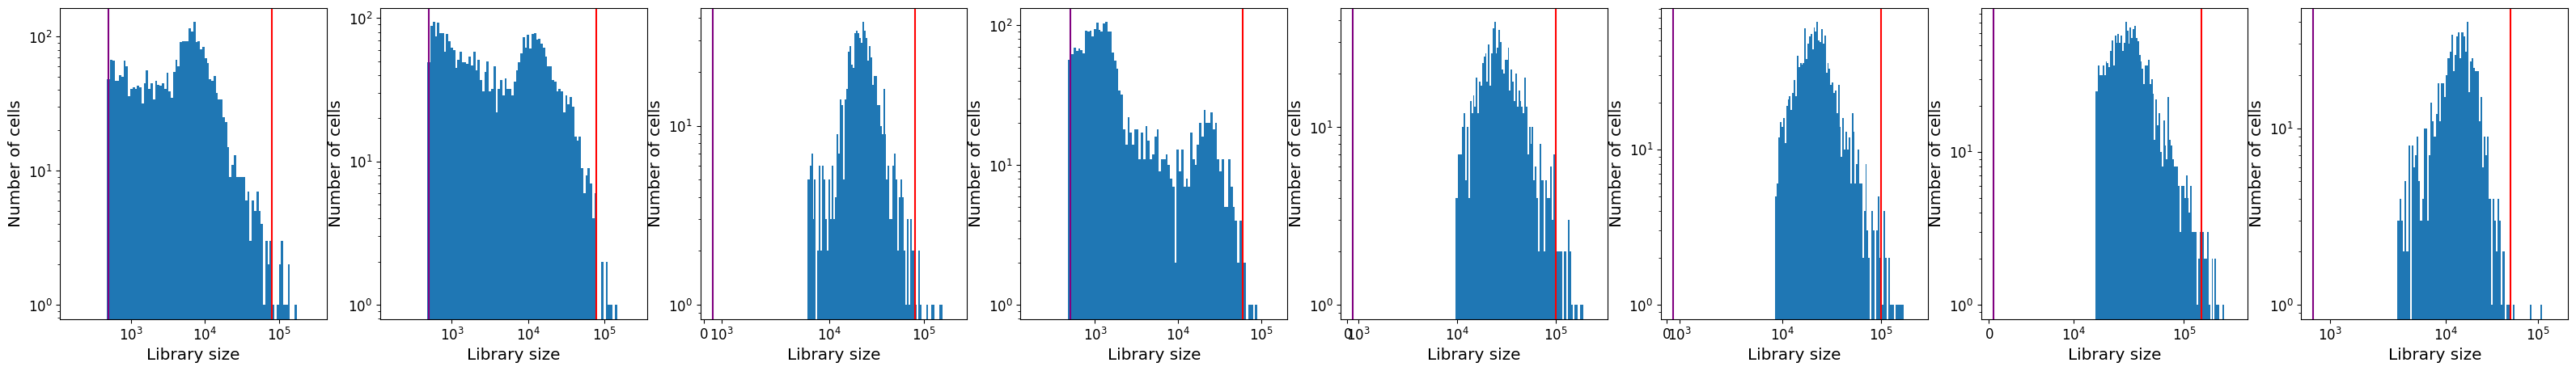

In [21]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(1, len(data_list), figsize=(5 * len(data_list), 5))
thresholds = [
    (500, 8e4),
    (500, 8e4),
    (500, 8e4),
    (500, 6e4),
    (500, 1e5),
    (500, 1e5),
    (500, 1.5e5),
    (500, 0.5e5),
]
for (s, dat), (ax, th) in zip(data_list.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color="red")
    ax.axvline(th[0], color="purple")

before lib filtGSM5176718_gastruloid_0h_1: (3183, 32738)
after lib filt GSM5176718_gastruloid_0h_1: (3169, 32738)
after gene filt GSM5176718_gastruloid_0h_1: (3169, 16383)
before lib filtGSM5176719_gastruloid_0h_2: (3381, 32738)
after lib filt GSM5176719_gastruloid_0h_2: (3373, 32738)
after gene filt GSM5176719_gastruloid_0h_2: (3373, 17785)
before lib filtGSM5176720_gastruloid_12h_1: (784, 33694)
after lib filt GSM5176720_gastruloid_12h_1: (774, 33694)
after gene filt GSM5176720_gastruloid_12h_1: (774, 15087)
before lib filtGSM5176721_gastruloid_12h_2: (2492, 32738)
after lib filt GSM5176721_gastruloid_12h_2: (2484, 32738)
after gene filt GSM5176721_gastruloid_12h_2: (2484, 14852)
before lib filtGSM5176722_gastruloid_24h_1: (975, 33694)
after lib filt GSM5176722_gastruloid_24h_1: (951, 33694)
after gene filt GSM5176722_gastruloid_24h_1: (951, 15548)
before lib filtGSM5176723_gastruloid_24h_2: (1608, 33694)
after lib filt GSM5176723_gastruloid_24h_2: (1590, 33694)
after gene filt GSM51

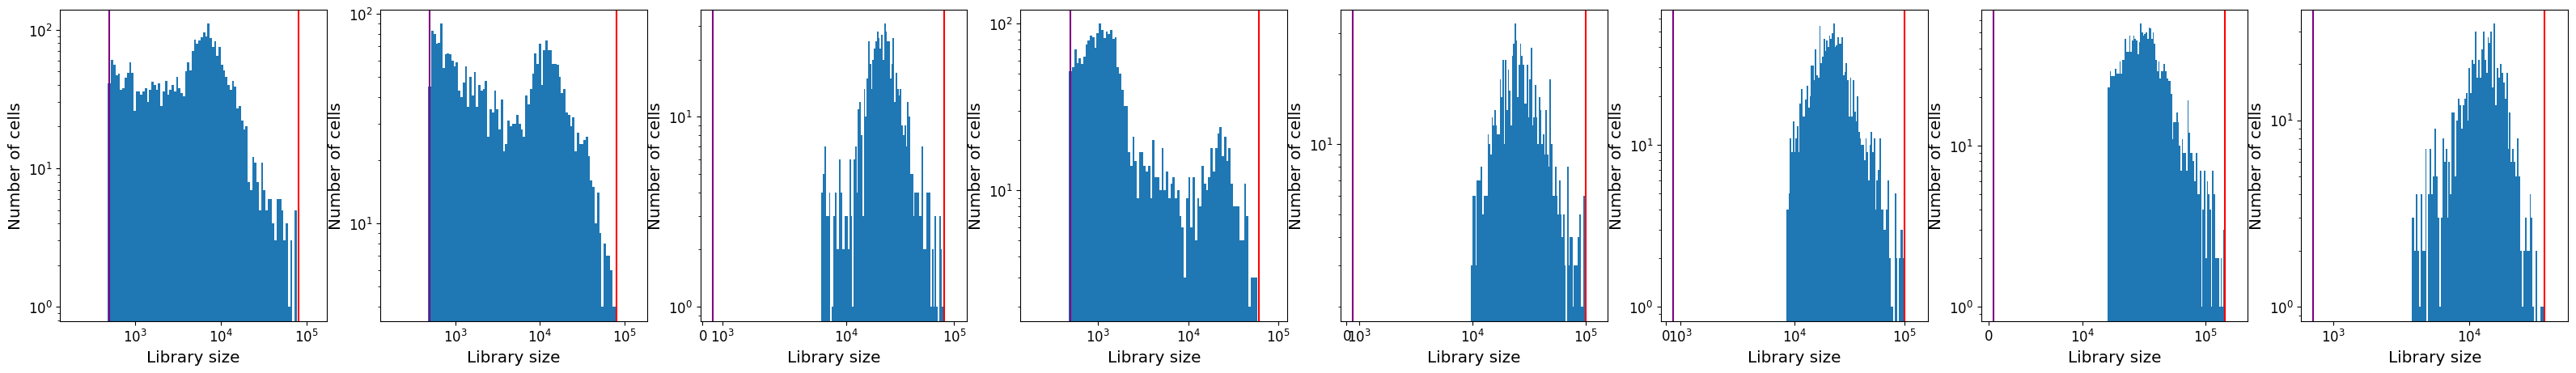

In [22]:
data_list_filt = {}
for (s, dat), th in zip(data_list.items(), thresholds):
    print(f"before lib filt{s}: {dat.shape}")
    dat = scprep.filter.filter_library_size(data=dat, cutoff=th)
    print(f"after lib filt {s}: {dat.shape}")
    dat = scprep.filter.remove_rare_genes(dat, cutoff=0, min_cells=5)
    print(f"after gene filt {s}: {dat.shape}")
    data_list_filt[s] = dat

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), (ax, th) in zip(data_list_filt.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color="red")
    ax.axvline(th[0], color="purple")

before mito filtGSM5176718_gastruloid_0h_1: (3169, 16383)
after mito filt GSM5176718_gastruloid_0h_1: (3041, 16383)
before mito filtGSM5176719_gastruloid_0h_2: (3373, 17785)
after mito filt GSM5176719_gastruloid_0h_2: (3238, 17785)
before mito filtGSM5176720_gastruloid_12h_1: (774, 15087)
after mito filt GSM5176720_gastruloid_12h_1: (743, 15087)
before mito filtGSM5176721_gastruloid_12h_2: (2484, 14852)
after mito filt GSM5176721_gastruloid_12h_2: (2384, 14852)
before mito filtGSM5176722_gastruloid_24h_1: (951, 15548)
after mito filt GSM5176722_gastruloid_24h_1: (912, 15548)
before mito filtGSM5176723_gastruloid_24h_2: (1590, 16147)
after mito filt GSM5176723_gastruloid_24h_2: (1526, 16147)
before mito filtGSM4300502_gastruloid1_44h: (1971, 18079)
after mito filt GSM4300502_gastruloid1_44h: (1892, 18079)
before mito filtGSM4300503_gastruloid2_44h: (818, 15459)
after mito filt GSM4300503_gastruloid2_44h: (784, 15459)


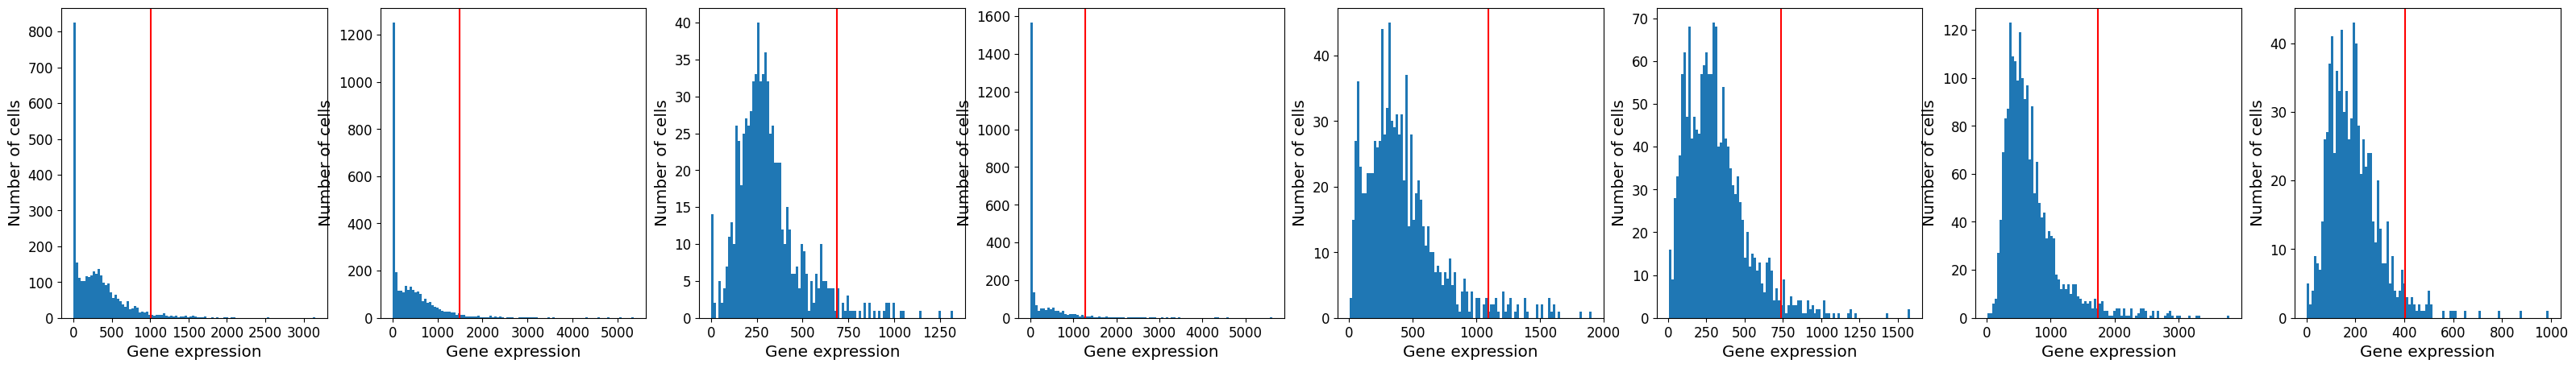

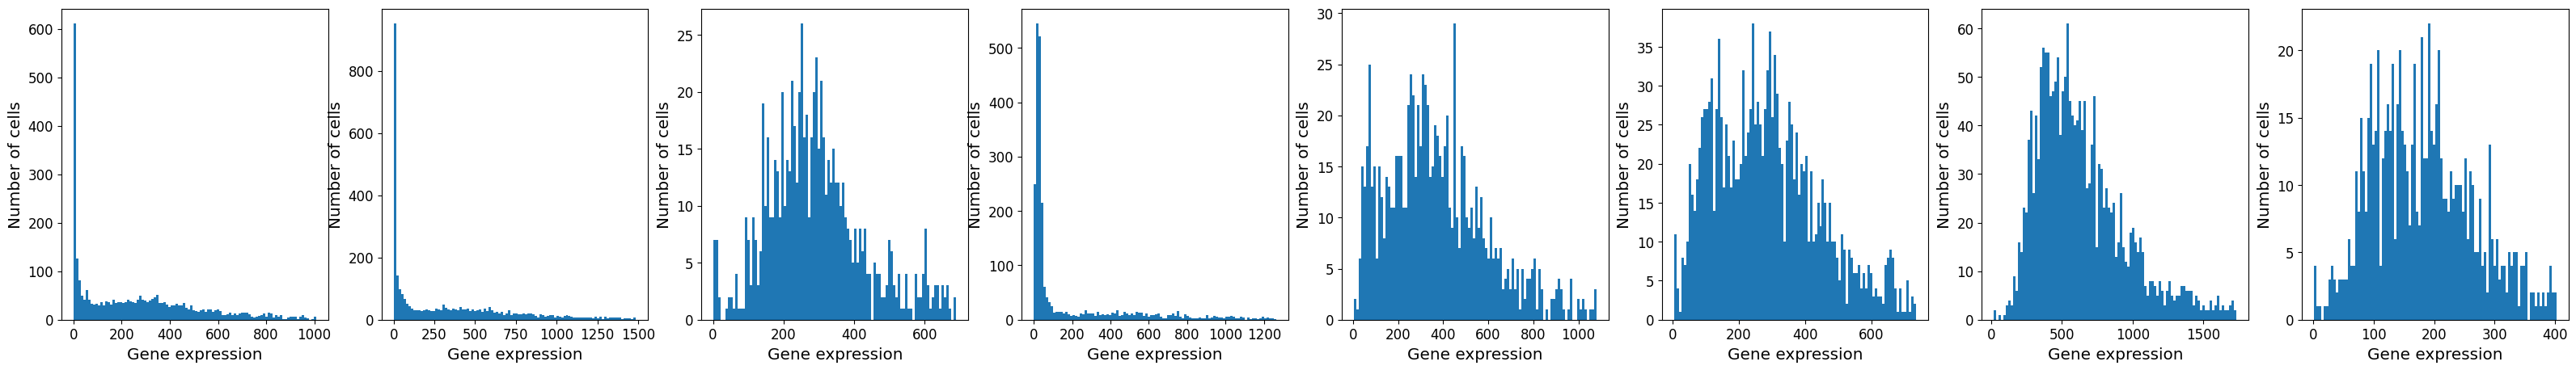

In [23]:
mt_genes = list(
    set.intersection(
        *[
            set(s)
            for s in [
                [g for g in dat.columns if g.startswith("MT-")]
                for dat in data_list_filt.values()
            ]
        ]
    )
)

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, percentile=96, ax=ax)

for s, dat in data_list_filt.items():
    print(f"before mito filt{s}: {dat.shape}")
    dat = scprep.filter.filter_gene_set_expression(
        data=dat, genes=mt_genes, percentile=96, keep_cells="below"
    )
    print(f"after mito filt {s}: {dat.shape}")
    data_list_filt[s] = dat

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, ax=ax)

In [ ]:
# read paper's meta
import pandas as pd
from anndata import AnnData

adata_list = []
for s, dat in data_list_filt.items():
    adata = AnnData(dat)
    adata.obs["sample_labels"] = s
    adata.obs["barcode"] = adata.obs.index
    if s in ["GSM4300502_gastruloid1_44h", "GSM4300503_gastruloid2_44h"]:
        adata.obs["stage"] = s.split("_")[-1]
        if s == "GSM4300502_gastruloid1_44h":
            adata.obs["Time and replicate"] = "44h Gastruloid Rep 1"
        elif s == "GSM4300503_gastruloid2_44h":
            adata.obs["Time and replicate"] = "44h Gastruloid Rep 2"
    else:
        adata.obs["Time and replicate"] = (
            s.split("_")[-2] + " Gastruloid Rep " + s.split("_")[-1]
        )
        adata.obs["stage"] = s.split("_")[-2]
    rep_id = [s[-1] for s in adata.obs["sample_labels"].str.split("_")]
    adata.obs.index = pd.Index(
        adata.obs.index.str.cat(adata.obs["sample_labels"], sep="_")
    )
    adata_list.append(adata)
adata = sc.concat(adata_list)
# merge meta
meta = pd.read_csv(data_path / "GSE169074_gastruloid.all.time.metadata.csv.gz")
meta["barcode"] = [s[0] for s in meta["Cell ID"].str.split("_")]
meta = adata.obs.merge(meta, how="left", on=["barcode", "Time and replicate"])
meta.index = adata.obs.index
adata.obs = meta
# the name is minn_gastruloid_0-24h_qc_20260213.h5ad (also contains 44h data)
mic.io.upload_minn_adata(adata, processing_stage="qc")

Saving AnnData to /tmp/tmpviv1loa3/minn_gastruloid_0-24h_qc_20260213.h5ad
Uploading to s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260213.h5ad


100%|██████████| 1/1 [00:17<00:00, 17.88s/it]

Upload complete: s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260213.h5ad


In [34]:
adata

AnnData object with n_obs × n_vars = 14520 × 12772
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'

# Integration

In [6]:
mic.io.fetch_minn(cwd, type="adata", stage="qc")

100%|██████████| 1/1 [05:09<00:00, 309.92s/it]


In [7]:
mic.io.fetch_heemskerk(cwd)

100%|██████████| 1/1 [12:36<00:00, 756.95s/it]


100%|██████████| 1/1 [00:02<00:00,  2.46s/it]


100%|██████████| 1/1 [00:53<00:00, 53.20s/it]


100%|██████████| 1/1 [01:15<00:00, 75.03s/it]


In [47]:
adata_minn = mic.io.MINN_ADATA_LIST["qc"]
adata_heemskerk_D2_D10 = mic.io.HEEMSKERK_ADATA_D2_D10["adata"]
meta_heemskerk_D2_D10 = mic.io.HEEMSKERK_ADATA_D2_D10["meta"]
adata_heemskerk_42h = mic.io.HEEMSKERK_ADATA_42H
minn_data_path = cwd / "minn_data"
heemskerk_data_path = cwd / "heemskerk_data"
adata_minn = sc.read_h5ad(minn_data_path / adata_minn)
adata_heemskerk_d2_d10 = sc.read_h5ad(heemskerk_data_path / adata_heemskerk_D2_D10)
meta_heemskerk_d2_d10 = pd.read_csv(heemskerk_data_path / meta_heemskerk_D2_D10, index_col=0)
adata_heemskerk_d2_d10.obs = meta_heemskerk_d2_d10.loc[adata_heemskerk_d2_d10.obs.index]
adata_heemskerk_42h_list = []
for s, f in adata_heemskerk_42h.items():
    adata_tmp = sc.read_h5ad(heemskerk_data_path / f)
    adata_tmp.obs["sample_labels"] = adata_tmp.obs["sample_labels"].str.cat(["_42h"] * adata_tmp.shape[0])
    adata_heemskerk_42h_list.append(adata_tmp)
adata_heemskerk_42h = sc.concat(adata_heemskerk_42h_list)

print(adata_minn)
print(adata_heemskerk_d2_d10)
print(adata_heemskerk_42h)
print(
    f"{len(set.intersection(set(adata_heemskerk_d2_d10.var_names), set(adata_heemskerk_42h.var_names), set(adata_minn.var_names)))} genes in common"
)
adata_heemskerk_d2_d10.obs["source"] = "heemskerk"
adata_heemskerk_42h.obs["source"] = "heemskerk"
adata_minn.obs["source"] = "minn"
adata = sc.concat([adata_heemskerk_d2_d10, adata_heemskerk_42h, adata_minn])
print(adata)
adata.obs = pd.concat([adata_heemskerk_d2_d10.obs, adata_heemskerk_42h.obs, adata_minn.obs])

AnnData object with n_obs × n_vars = 14520 × 12772
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'
AnnData object with n_obs × n_vars = 62402 × 16519
    obs: 'sample_labels', 'leiden_sub', 'leiden_sub_sub2', 'branch_joint', 'dpt_pseudotime', 'leiden_sub_colors', 'leiden_sub_sub2_colors', 'umap_old_48-96h_x', 'umap_old_48-96h_y', 'umap_new_D4-10_x', 'umap_new_D4-10_y'
AnnData object with n_obs × n_vars = 10815 × 20685
    obs: 'sample_labels'
11230 genes in common
AnnData object with n_obs × n_vars = 87737 × 11230
    obs: 'sample_labels', 'source'


In [48]:
adata.obs["sample_labels"].value_counts()

,count
sample_labels,
72h-2,11505
48h-2,9850
bc_2,8702
96h-2,8481
72h-1,6166
48h-1,5927
BMP4_42h,5488
2020-FC-9000_42h,5327
96h-1,4579


In [49]:
cc_genes = mic.io.read_cc_list(cwd)

100%|██████████| 1/1 [00:00<00:00,  3.68it/s]


In [50]:
mic.utils.normalize_and_select_hvg(adata, n_top_genes=500)

2026-02-14 00:49:39.844 | INFO     | micropattern.utils:normalize_and_select_hvg:56 - Copying X to counts layer before normalization
2026-02-14 00:49:41.486 | INFO     | micropattern.utils:normalize_and_select_hvg:60 - Normalizing to target sum 10000.0 and applying log1p transformation
2026-02-14 00:49:44.838 | INFO     | micropattern.utils:normalize_and_select_hvg:82 - Saving X to raw before computing HVG
2026-02-14 00:49:44.840 | INFO     | micropattern.utils:normalize_and_select_hvg:86 - Computing top 500 highly variable genes (seurat_v3)


In [51]:
cc_genes_all = [g for gl in cc_genes.values() for g in gl]
cc_genes_all = [
    g
    for g in adata.var_names
    if g.split()[0] in cc_genes_all and g not in adata.obs.columns
]
print(f"Insert {len(cc_genes_all)} cc genes into obs")
adata.obs = pd.concat([adata.obs, adata[:, cc_genes_all].to_df()], axis=1)

Insert 33 cc genes into obs


In [ ]:
mic.integration.integration(
    adata,
    run_name="minn_heemskerk_micropatern_0-10d_650hvg_40lv",
    categorical_covariates_keys=None,
    continuous_covariates_keys=cc_genes_all,
    n_latent=60,
    lr=1e-6,
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: Th

Training:   0%|          | 0/400 [00:00<?, ?it/s]

In [35]:
sc.set_figure_params(figsize=(5, 5))

In [36]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_scvi", random_state=1)

In [40]:
sc.tl.umap(adata, min_dist=0.01, random_state=1)

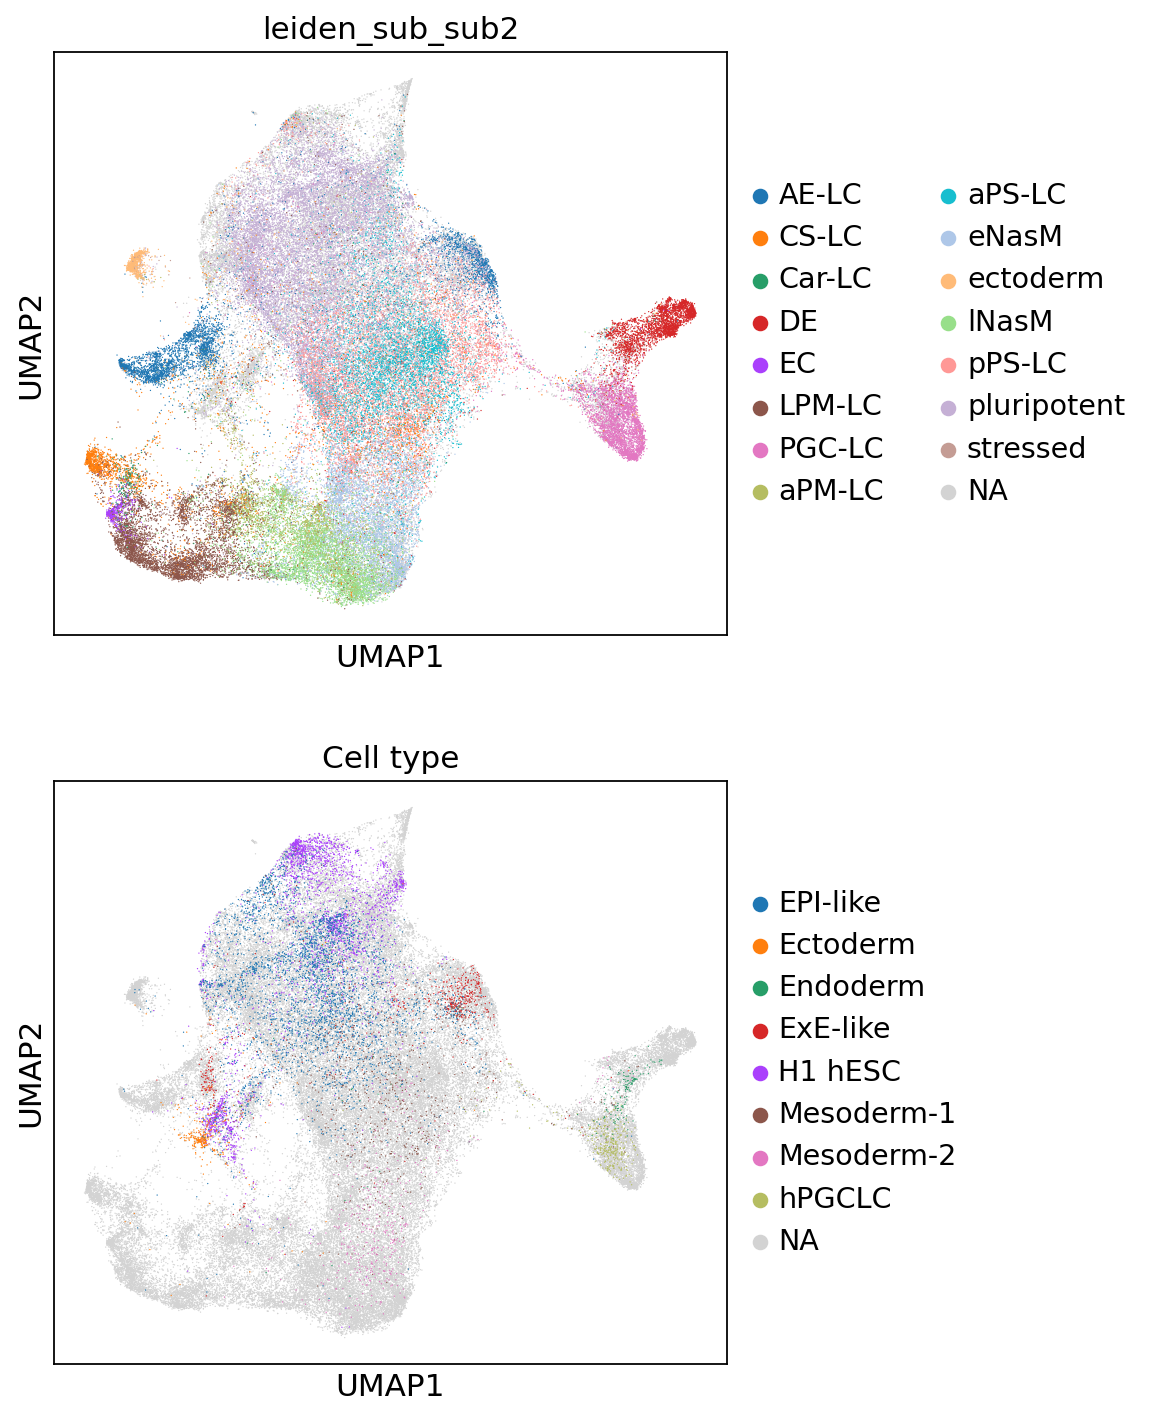

In [41]:
sc.pl.umap(adata, color=["leiden_sub_sub2", "Cell type"], ncols=1)

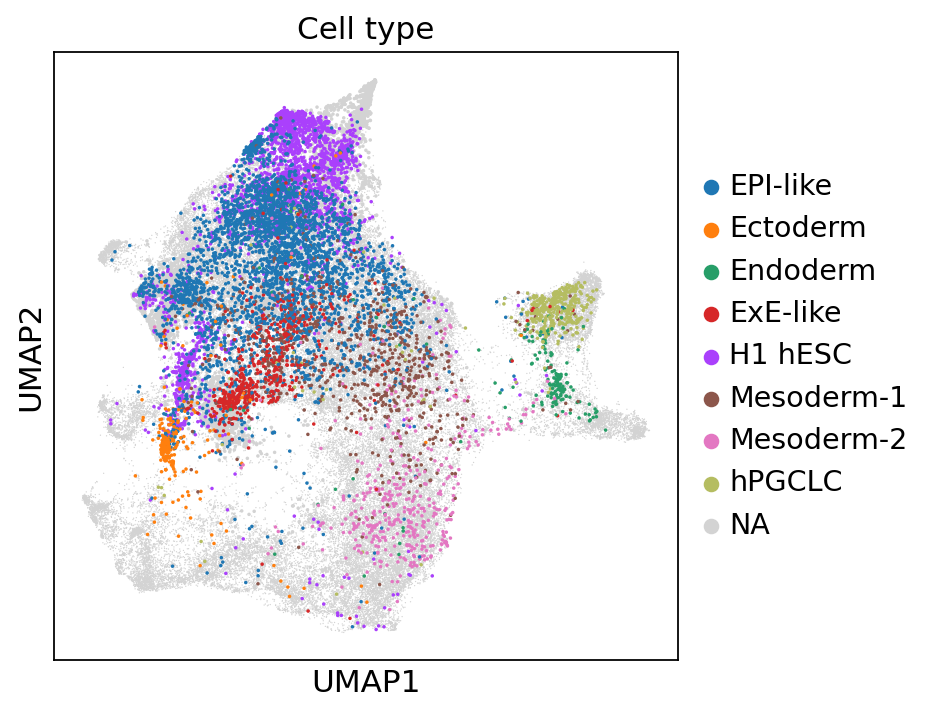

In [26]:
ax = sc.pl.umap(adata, show=False)
sc.pl.umap(
    adata[adata.obs["sample_labels"].str.contains("GSM")],
    color="Cell type",
    ax=ax,
    size=10,
)